In [6]:
import os
print(os.getcwd())

C:\Users\HUAWEI


In [7]:
#Import data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

daily = pd.read_csv(r"C:\starbucks-data-project\data\sbux_daily.csv")
monthly = pd.read_csv(r"C:\starbucks-data-project\data\sbux_monthly.csv")
security = pd.read_csv(r"C:\starbucks-data-project\data\sbux_security.csv")

In [8]:
print(daily.head())
print(daily.columns)
print(monthly.head())
print(security.head())

   gvkey  iid    datadate  prccd     cshtrd
0  25434    1  2018-01-02  57.63  7206985.0
1  25434    1  2018-01-03  58.71  7464021.0
2  25434    1  2018-01-04  58.93  5769653.0
3  25434    1  2018-01-05  59.61  6046984.0
4  25434    1  2018-01-08  59.31  6302806.0
Index(['gvkey', 'iid', 'datadate', 'prccd', 'cshtrd'], dtype='object')
   gvkey  iid    datadate   tic      cusip            conm  ajexm  ajpm  \
0  25434    1  2018-01-31  SBUX  855244109  STARBUCKS CORP    1.0   1.0   
1  25434    1  2018-02-28  SBUX  855244109  STARBUCKS CORP    1.0   1.0   
2  25434    1  2018-03-31  SBUX  855244109  STARBUCKS CORP    1.0   1.0   
3  25434    1  2018-04-30  SBUX  855244109  STARBUCKS CORP    1.0   1.0   
4  25434    1  2018-05-31  SBUX  855244109  STARBUCKS CORP    1.0   1.0   

   isalrt primiss  ...  adrrm cmth         cshom  cyear  mkvalincl  exchg  \
0     NaN       P  ...    NaN    1  1.405314e+09   2018          Y     14   
1     NaN       P  ...    NaN    2  1.405600e+09   2018     

In [70]:
# 1. Unified listing
daily.columns = daily.columns.str.strip().str.lower().str.replace(' ', '_')
monthly.columns = monthly.columns.str.strip().str.lower().str.replace(' ', '_')
security.columns = security.columns.str.strip().str.lower().str.replace(' ', '_')

# 2. View basic information
print(daily.info())
print(monthly.info())
print(security.info())

# 3. Missing value checking
print("daily missing values:")
print(daily.isnull().sum())

print("monthly missing values:")
print(monthly.isnull().sum())

print("security missing values:")
print(security.isnull().sum())

# 4. Duplicate value check
print("daily duplicates:", daily.duplicated().sum())
print("monthly duplicates:", monthly.duplicated().sum())
print("security duplicates:", security.duplicated().sum())

# 5. Remove entire rows of duplicates
donthly = monthly.drop_duplicates()
security = security.drop_duplicates()

# 6. Date conversion (modify according to actual column name)
if 'date' in daily.columns:
    daily['date'] = pd.to_datetime(daily['date'], errors='coerce')

if 'date' in monthly.columns:
    monthly['date'] = pd.to_datetime(monthly['date'], errors='coerce')

# 7. Delete key fields missing
if 'date' in daily.columns:
    daily = daily.dropna(subset=['date'])

if 'date' in monthly.columns:
    monthly = monthly.dropna(subset=['date'])

# 8. sort
if 'date' in daily.columns:
    daily = daily.sort_values('date').reset_index(drop=True)

if 'date' in monthly.columns:
    monthly = monthly.sort_values('date').reset_index(drop=True)

# 9. Check again
print(daily.head())
print(monthly.head())
print(security.head())
daily = daily.drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2085 entries, 0 to 2084
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   gvkey     2085 non-null   int64  
 1   iid       2085 non-null   int64  
 2   datadate  2085 non-null   object 
 3   prccd     2084 non-null   float64
 4   cshtrd    2084 non-null   float64
dtypes: float64(2), int64(2), object(1)
memory usage: 81.6+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 45 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   gvkey      99 non-null     int64  
 1   iid        99 non-null     int64  
 2   datadate   99 non-null     object 
 3   tic        99 non-null     object 
 4   cusip      99 non-null     int64  
 5   conm       99 non-null     object 
 6   ajexm      99 non-null     float64
 7   ajpm       99 non-null     float64
 8   isalrt     0 non-null      float64
 9   primi

In [9]:
for col in ['open', 'high', 'low', 'close', 'volume']:
    if col in daily.columns:
        daily[col] = pd.to_numeric(daily[col], errors='coerce')

In [12]:
print(list(daily.columns))

['gvkey', 'iid', 'datadate', 'prccd', 'cshtrd']


In [11]:
print(daily.drop(columns=['gvkey'], errors='ignore').head())

   iid    datadate  prccd     cshtrd
0    1  2018-01-02  57.63  7206985.0
1    1  2018-01-03  58.71  7464021.0
2    1  2018-01-04  58.93  5769653.0
3    1  2018-01-05  59.61  6046984.0
4    1  2018-01-08  59.31  6302806.0


In [14]:
print(daily.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2085 entries, 0 to 2084
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   gvkey     2085 non-null   int64  
 1   iid       2085 non-null   int64  
 2   datadate  2085 non-null   object 
 3   prccd     2084 non-null   float64
 4   cshtrd    2084 non-null   float64
dtypes: float64(2), int64(2), object(1)
memory usage: 81.6+ KB
None


In [15]:
daily.columns = daily.columns.str.strip().str.lower().str.replace(' ', '_')
monthly.columns = monthly.columns.str.strip().str.lower().str.replace(' ', '_')
security.columns = security.columns.str.strip().str.lower().str.replace(' ', '_')

In [10]:
print(daily.drop(columns=['gvkey'], errors='ignore').describe(include='all'))

           iid    datadate        prccd        cshtrd
count   2085.0        2085  2084.000000  2.084000e+03
unique     NaN        2085          NaN           NaN
top        NaN  2018-01-02          NaN           NaN
freq       NaN           1          NaN           NaN
mean       1.0         NaN    88.037726  8.866390e+06
std        0.0         NaN    16.569016  5.898834e+06
min        1.0         NaN    48.540000  1.847770e+06
25%        1.0         NaN    77.680000  5.863907e+06
50%        1.0         NaN    89.470000  7.606895e+06
75%        1.0         NaN    98.802500  1.018912e+07
max        1.0         NaN   126.060000  1.568314e+08


In [17]:
daily['daily_return'] = daily.groupby(['gvkey', 'iid'])['prccd'].pct_change()
print(daily[['datadate', 'prccd', 'daily_return']].head(10))

     datadate  prccd  daily_return
0  2018-01-02  57.63           NaN
1  2018-01-03  58.71      0.018740
2  2018-01-04  58.93      0.003747
3  2018-01-05  59.61      0.011539
4  2018-01-08  59.31     -0.005033
5  2018-01-09  59.18     -0.002192
6  2018-01-10  59.82      0.010814
7  2018-01-11  60.00      0.003009
8  2018-01-12  60.40      0.006667
9  2018-01-16  60.56      0.002649


C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_44132\3345106729.py:1: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily['daily_return'] = daily.groupby(['gvkey', 'iid'])['prccd'].pct_change()


In [13]:
#Calculation function for daily stocks (applicable to single stocks and multiple stocks)
def calculate_daily_return(df, price_col='prccd', group_cols=None, date_col='datadate', stock_col=None, stock_value=None):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    
    # If a certain stock is specified, screen first
    if stock_col is not None and stock_value is not None:
        df = df[df[stock_col] == stock_value].copy()
    
    # If there is a grouping column, calculate it based on the grouping column.
    if group_cols is not None and len(group_cols) > 0:
        df = df.sort_values(group_cols + [date_col])
        df['daily_return'] = df.groupby(group_cols)[price_col].pct_change()
    else:
        df = df.sort_values(date_col)
        df['daily_return'] = df[price_col].pct_change()
    
    return df

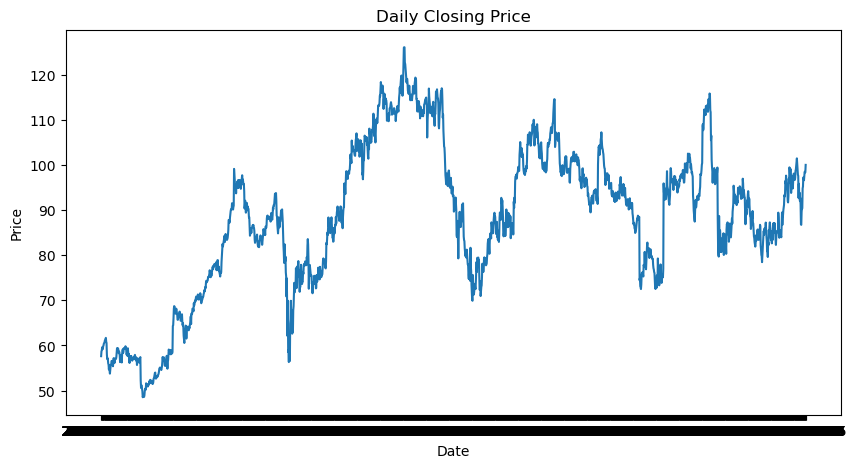

In [18]:
#price chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(daily['datadate'], daily['prccd'])
plt.title('Daily Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

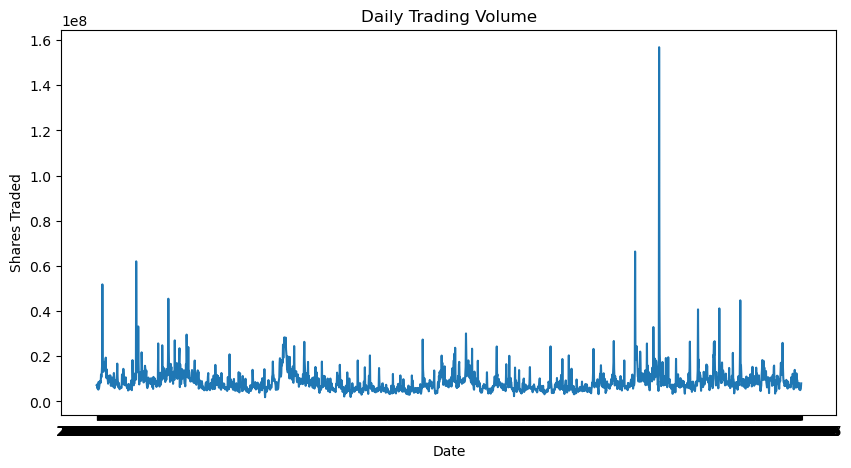

In [19]:
#Trading volume trend chart
plt.figure(figsize=(10,5))
plt.plot(daily['datadate'], daily['cshtrd'])
plt.title('Daily Trading Volume')
plt.xlabel('Date')
plt.ylabel('Shares Traded')
plt.show()

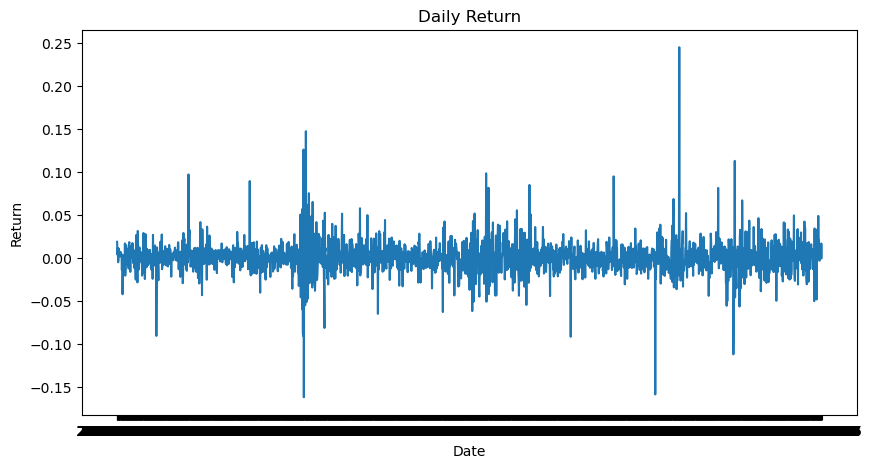

In [20]:
#Daily income chart
plt.figure(figsize=(10,5))
plt.plot(daily['datadate'], daily['daily_return'])
plt.title('Daily Return')
plt.xlabel('Date')
plt.ylabel('Return')
plt.show()

In [21]:
#Daily income sorting
print(daily.sort_values('daily_return', ascending=False).head())
print(daily.sort_values('daily_return', ascending=True).head())

      gvkey  iid    datadate  prccd       cshtrd  daily_return
1663  25434    1  2024-08-13  95.90  156831400.0      0.244969
559   25434    1  2020-03-24  64.88   28240040.0      0.147303
552   25434    1  2020-03-13  69.92   19212220.0      0.125926
1827  25434    1  2025-04-09  88.68   26656230.0      0.112812
1092  25434    1  2022-05-04  81.64   30087550.0      0.098345
      gvkey  iid    datadate   prccd      cshtrd  daily_return
553   25434    1  2020-03-16   58.59  23337020.0     -0.162042
1592  25434    1  2024-05-01   74.44  66366430.0     -0.158775
1823  25434    1  2025-04-03   88.26  20484090.0     -0.112162
1342  25434    1  2023-05-03  103.96  24355390.0     -0.091735
551   25434    1  2020-03-12   62.10  25138520.0     -0.090776


In [22]:
#Check for extreme values
print((daily['daily_return'].abs() > 0.1).sum())

extreme = daily[daily['daily_return'].abs() > 0.1]
print(extreme[['gvkey', 'iid', 'datadate', 'prccd', 'cshtrd', 'daily_return']])

7
      gvkey  iid    datadate  prccd       cshtrd  daily_return
552   25434    1  2020-03-13  69.92   19212220.0      0.125926
553   25434    1  2020-03-16  58.59   23337020.0     -0.162042
559   25434    1  2020-03-24  64.88   28240040.0      0.147303
1592  25434    1  2024-05-01  74.44   66366430.0     -0.158775
1663  25434    1  2024-08-13  95.90  156831400.0      0.244969
1823  25434    1  2025-04-03  88.26   20484090.0     -0.112162
1827  25434    1  2025-04-09  88.68   26656230.0      0.112812


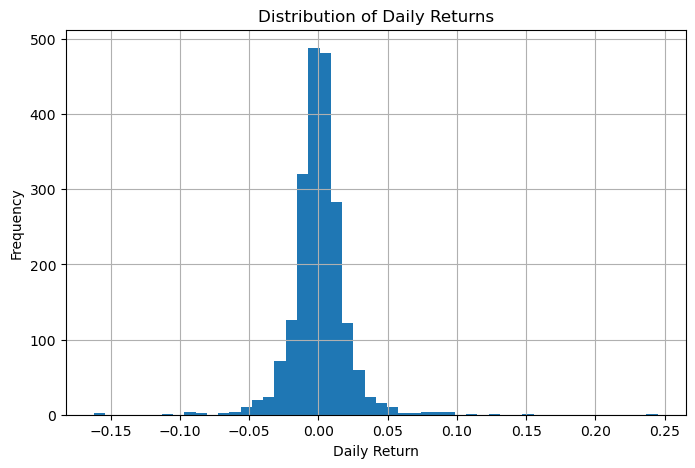

In [23]:
#Yield distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
daily['daily_return'].hist(bins=50)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

In [25]:
daily.to_csv("C:\starbucks-data-project\daily_with_return.csv", index=False)

In [26]:
summary_stats = daily[['prccd', 'cshtrd', 'daily_return']].describe()
print(summary_stats)

             prccd        cshtrd  daily_return
count  2084.000000  2.084000e+03   2084.000000
mean     88.037726  8.866390e+06      0.000458
std      16.569016  5.898834e+06      0.019728
min      48.540000  1.847770e+06     -0.162042
25%      77.680000  5.863907e+06     -0.008744
50%      89.470000  7.606895e+06      0.000414
75%      98.802500  1.018912e+07      0.009121
max     126.060000  1.568314e+08      0.244969


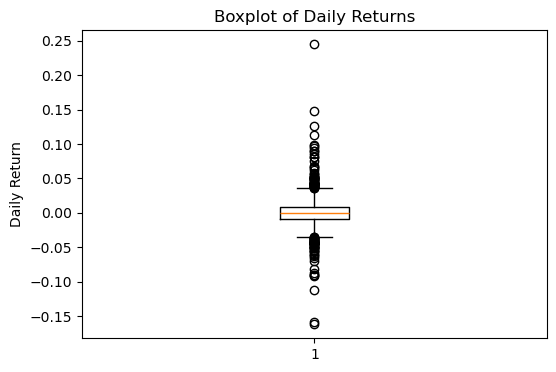

In [28]:
#boxplot
plt.figure(figsize=(6,4))
plt.boxplot(daily['daily_return'].dropna())
plt.title('Boxplot of Daily Returns')
plt.ylabel('Daily Return')
plt.show()

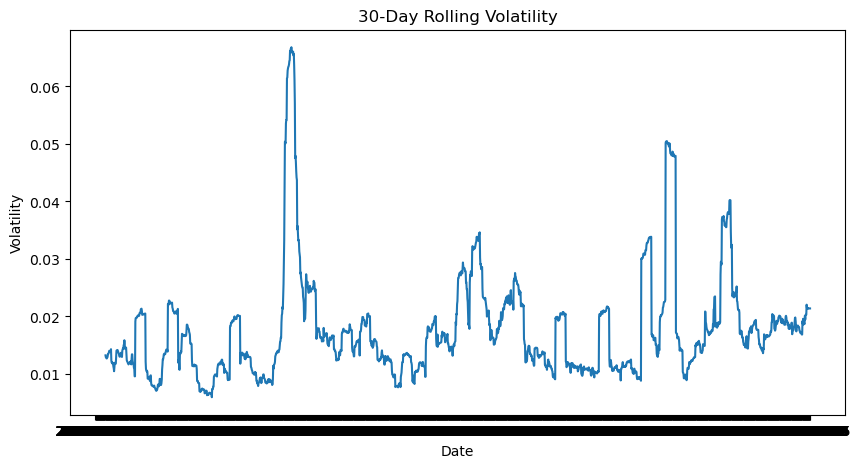

In [29]:
#Volatility analysis
daily['rolling_vol_30'] = daily['daily_return'].rolling(window=30).std()

plt.figure(figsize=(10,5))
plt.plot(daily['datadate'], daily['rolling_vol_30'])
plt.title('30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

In [34]:
#Average return by year
daily['year'] = daily['datadate'].dt.year
print(daily.groupby('year')['daily_return'].mean())
#Volatility statistics by year
print(daily.groupby('year')['daily_return'].std())
#Average trading volume by year
print(daily.groupby('year')['cshtrd'].mean())

year
2018    0.000554
2019    0.001309
2020    0.001186
2021    0.000456
2022   -0.000404
2023   -0.000029
2024    0.000063
2025   -0.000089
2026    0.002507
Name: daily_return, dtype: float64
year
2018    0.014836
2019    0.012128
2020    0.028645
2021    0.014258
2022    0.022605
2023    0.014282
2024    0.023528
2025    0.021567
2026    0.019197
Name: daily_return, dtype: float64
year
2018    1.117316e+07
2019    7.949043e+06
2020    9.609449e+06
2021    6.067148e+06
2022    8.757021e+06
2023    6.550901e+06
2024    1.074178e+07
2025    1.007462e+07
2026    8.883581e+06
Name: cshtrd, dtype: float64


In [35]:
print(list(monthly.columns))
print(monthly.head())
print(monthly.info())

['gvkey', 'iid', 'datadate', 'tic', 'cusip', 'conm', 'ajexm', 'ajpm', 'isalrt', 'primiss', 'cheqvm', 'curcddvm', 'dvpspm', 'dvpsxm', 'dvrate', 'csfsm', 'cshtrm', 'curcdm', 'navm', 'prccm', 'prchm', 'prclm', 'trfm', 'trt1m', 'rawpm', 'rawxm', 'sph100', 'sphcusip', 'sphiid', 'sphmid', 'sphname', 'sphsec', 'sphtic', 'sphvg', 'cshoq', 'adrrm', 'cmth', 'cshom', 'cyear', 'mkvalincl', 'exchg', 'secstat', 'tpci', 'cik', 'fic']
   gvkey  iid    datadate   tic      cusip            conm  ajexm  ajpm  \
0  25434    1  2018-01-31  SBUX  855244109  STARBUCKS CORP    1.0   1.0   
1  25434    1  2018-02-28  SBUX  855244109  STARBUCKS CORP    1.0   1.0   
2  25434    1  2018-03-31  SBUX  855244109  STARBUCKS CORP    1.0   1.0   
3  25434    1  2018-04-30  SBUX  855244109  STARBUCKS CORP    1.0   1.0   
4  25434    1  2018-05-31  SBUX  855244109  STARBUCKS CORP    1.0   1.0   

   isalrt primiss  ...  adrrm cmth         cshom  cyear  mkvalincl  exchg  \
0     NaN       P  ...    NaN    1  1.405314e+09 

In [14]:
#Monthly price and monthly yield functions
def calculate_monthly_return(df, price_col='prccd', group_cols=None, date_col='datadate', stock_col=None, stock_value=None):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    
    # If you specify a certain stock, screen it first
    if stock_col is not None and stock_value is not None:
        df = df[df[stock_col] == stock_value].copy()
    
    # Extract year and month
    df['year_month'] = df[date_col].dt.to_period('M')
    
    if group_cols is not None and len(group_cols) > 0:
        df = df.sort_values(group_cols + [date_col])
        
        # Price on the last trading day of each month
        monthly = df.groupby(group_cols + ['year_month']).last().reset_index()
        
        # Calculate monthly rate of return
        monthly = monthly.sort_values(group_cols + ['year_month'])
        monthly['monthly_return'] = monthly.groupby(group_cols)[price_col].pct_change()
    else:
        df = df.sort_values(date_col)
        
        # Price on the last trading day of each month
        monthly = df.groupby('year_month').last().reset_index()
        
        # Calculate monthly rate of return
        monthly = monthly.sort_values('year_month')
        monthly['monthly_return'] = monthly[price_col].pct_change()
    
    return monthly

Monthly summary statistics:
            prccm        cshtrm      trt1m
count   99.000000  9.900000e+01  99.000000
mean    88.094343  1.858672e+08   0.952937
std     16.625040  6.628932e+07   8.038982
min     48.850000  9.657109e+07 -18.391300
25%     77.970000  1.388837e+08  -3.495900
50%     88.490000  1.697284e+08   1.147800
75%     98.205000  2.057781e+08   5.817750
max    121.430000  4.454737e+08  22.052600


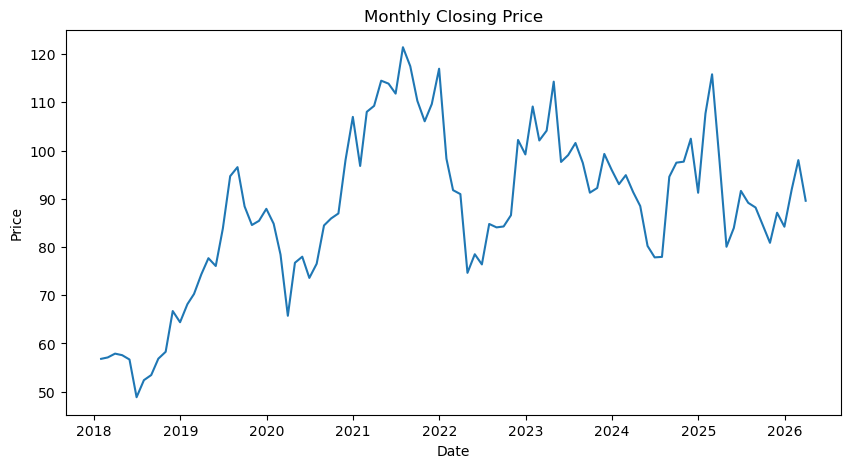

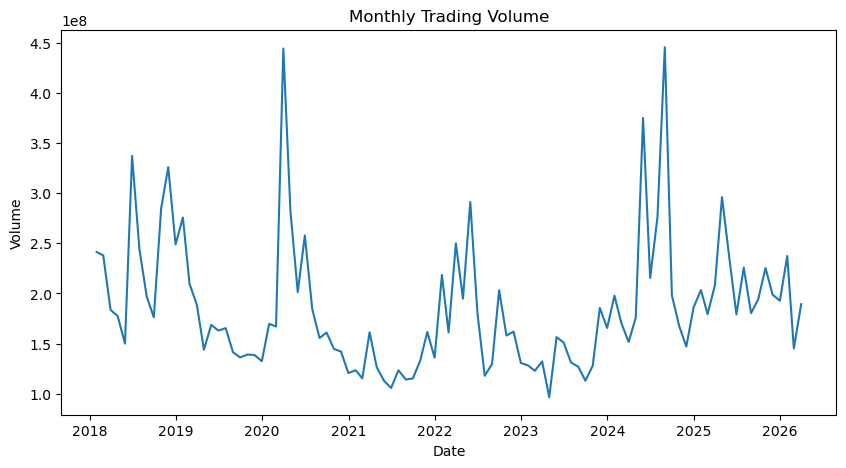

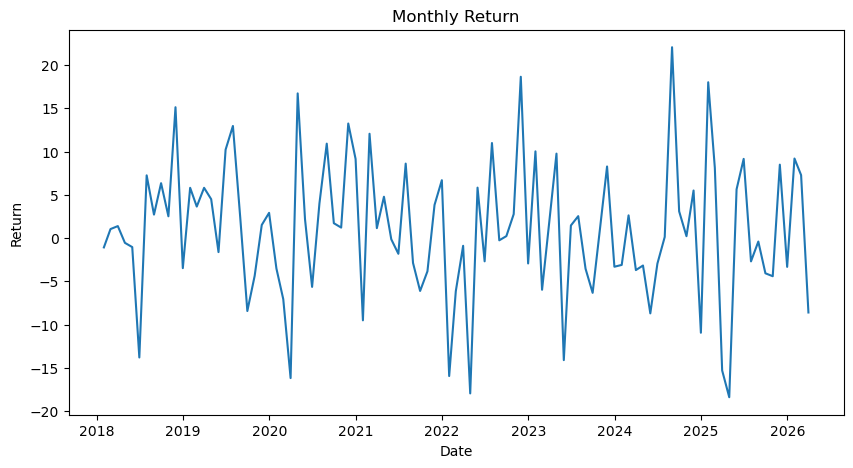

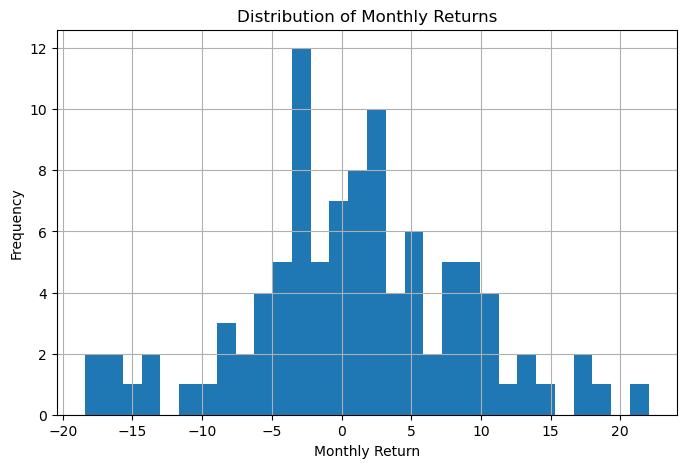

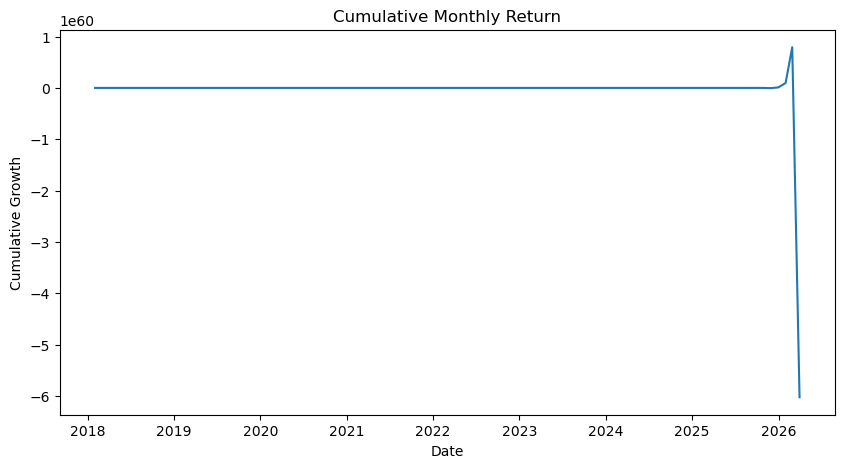


Average monthly return by year:
year
2018    1.367133
2019    2.940283
2020    2.225525
2021    1.066975
2022   -0.697717
2023    0.152500
2024    0.085917
2025    0.065558
2026    2.622233
Name: trt1m, dtype: float64

Monthly return volatility by year:
year
2018     6.879743
2019     5.865228
2020     9.432897
2021     6.347795
2022    10.156904
2023     7.234182
2024     8.369018
2025    10.463344
2026     9.766080
Name: trt1m, dtype: float64

Average monthly trading volume by year:
year
2018    2.337052e+08
2019    1.669299e+08
2020    2.025992e+08
2021    1.274101e+08
2022    1.831677e+08
2023    1.364771e+08
2024    2.255774e+08
2025    2.098879e+08
2026    1.906006e+08
Name: cshtrm, dtype: float64

Top 5 monthly returns:
     datadate   prccm       cshtrm    trt1m
79 2024-08-31   94.57  445473749.0  22.0526
58 2022-11-30  102.20  161970579.0  18.6396
84 2025-01-31  107.68  203401587.0  18.0055
27 2020-04-30   76.73  282022382.0  16.7174
10 2018-11-30   66.72  325880692.0  15.119

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Clean
monthly.columns = monthly.columns.str.strip().str.lower().str.replace(' ', '_')
monthly['datadate'] = pd.to_datetime(monthly['datadate'], errors='coerce')

for col in ['prccm', 'prchm', 'prclm', 'cshtrm', 'trt1m']:
    monthly[col] = pd.to_numeric(monthly[col], errors='coerce')

monthly = monthly.dropna(subset=['gvkey', 'iid', 'datadate', 'prccm', 'cshtrm', 'trt1m'])
monthly = monthly.drop_duplicates()
monthly = monthly.drop_duplicates(subset=['gvkey', 'iid', 'datadate'], keep='last')
monthly = monthly[(monthly['prccm'] > 0) & (monthly['cshtrm'] >= 0)]
monthly = monthly.sort_values(['gvkey', 'iid', 'datadate']).reset_index(drop=True)

# 2. Descriptive statistics
print("Monthly summary statistics:")
print(monthly[['prccm', 'cshtrm', 'trt1m']].describe())

# 3. End of month price chart
plt.figure(figsize=(10,5))
plt.plot(monthly['datadate'], monthly['prccm'])
plt.title('Monthly Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

# 4. Monthly trading volume chart
plt.figure(figsize=(10,5))
plt.plot(monthly['datadate'], monthly['cshtrm'])
plt.title('Monthly Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

# 5. Monthly yield chart
plt.figure(figsize=(10,5))
plt.plot(monthly['datadate'], monthly['trt1m'])
plt.title('Monthly Return')
plt.xlabel('Date')
plt.ylabel('Return')
plt.show()

# 6. Monthly yield distribution chart
plt.figure(figsize=(8,5))
monthly['trt1m'].hist(bins=30)
plt.title('Distribution of Monthly Returns')
plt.xlabel('Monthly Return')
plt.ylabel('Frequency')
plt.show()

# 7. Cumulative rate of return
monthly['cum_return'] = (1 + monthly['trt1m']).cumprod()

plt.figure(figsize=(10,5))
plt.plot(monthly['datadate'], monthly['cum_return'])
plt.title('Cumulative Monthly Return')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth')
plt.show()

# 8. annual statistics
monthly['year'] = monthly['datadate'].dt.year

print("\nAverage monthly return by year:")
print(monthly.groupby('year')['trt1m'].mean())

print("\nMonthly return volatility by year:")
print(monthly.groupby('year')['trt1m'].std())

print("\nAverage monthly trading volume by year:")
print(monthly.groupby('year')['cshtrm'].mean())

# 9. extreme monthly returns
print("\nTop 5 monthly returns:")
print(monthly.sort_values('trt1m', ascending=False)[['datadate', 'prccm', 'cshtrm', 'trt1m']].head())

print("\nBottom 5 monthly returns:")
print(monthly.sort_values('trt1m', ascending=True)[['datadate', 'prccm', 'cshtrm', 'trt1m']].head())

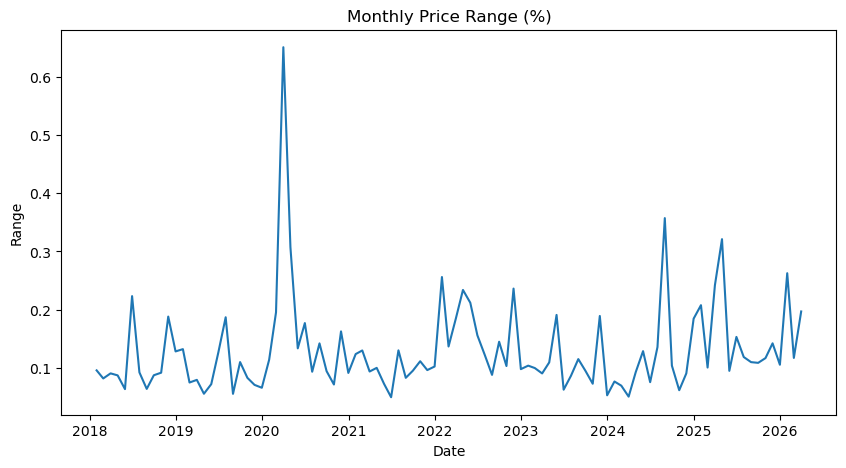

In [37]:
#High and low price fluctuation range
monthly['price_range_pct'] = (monthly['prchm'] - monthly['prclm']) / monthly['prclm']

plt.figure(figsize=(10,5))
plt.plot(monthly['datadate'], monthly['price_range_pct'])
plt.title('Monthly Price Range (%)')
plt.xlabel('Date')
plt.ylabel('Range')
plt.show()

In [69]:
# 1. Clean column names
security.columns = security.columns.str.strip().str.lower().str.replace(' ', '_')

# 2. Check basic situation
print("Columns:")
print(security.columns.tolist())

print("\nInfo:")
print(security.info())

print("\nMissing values in gvkey/iid:")
print(security[['gvkey', 'iid']].isnull().sum())

print("\nDuplicate rows:", security.duplicated().sum())
print("Duplicate by gvkey+iid:", security.duplicated(subset=['gvkey', 'iid']).sum())

# 3. Remove critical deletions and duplications
security = security.dropna(subset=['gvkey', 'iid'])
security = security.drop_duplicates()
security = security.drop_duplicates(subset=['gvkey', 'iid'], keep='last')

# 4. Select retained columns (according to actual existing fields)
keep_cols = [col for col in ['gvkey', 'iid', 'tic', 'conm', 'cusip', 'exchg', 'fic', 'secstat', 'tpci', 'primiss'] if col in security.columns]
security_clean = security[keep_cols].copy()

print("\nCleaned security data:")
print(security_clean.head())

# 5. View classification field distribution
for col in ['tic', 'conm', 'exchg', 'fic', 'secstat', 'primiss']:
    if col in security_clean.columns:
        print(f"\nValue counts for {col}:")
        print(security_clean[col].value_counts(dropna=False))

# 6. Merge to daily
daily_merged = daily.merge(security_clean, on=['gvkey', 'iid'], how='left')

# 7. Merge to monthly
monthly_merged = monthly.merge(security_clean, on=['gvkey', 'iid'], how='left')

print("\nMerged daily sample:")
print(daily_merged.head())

print("\nMerged monthly sample:")
print(monthly_merged.head())

Columns:
['tic', 'gvkey', 'iid', 'cusip', 'dlrsni', 'dsci', 'epf', 'exchg', 'excntry', 'ibtic', 'isin', 'secstat', 'sedol', 'tpci', 'dldtei', 'curr_sp500_flag']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tic              1 non-null      object 
 1   gvkey            1 non-null      int64  
 2   iid              1 non-null      int64  
 3   cusip            1 non-null      int64  
 4   dlrsni           0 non-null      float64
 5   dsci             1 non-null      object 
 6   epf              0 non-null      float64
 7   exchg            1 non-null      int64  
 8   excntry          1 non-null      object 
 9   ibtic            1 non-null      object 
 10  isin             1 non-null      object 
 11  secstat          1 non-null      object 
 12  sedol            1 non-null      int64  
 13  tpci             1 non-null      int

In [44]:
daily['datadate'] = pd.to_datetime(daily['datadate'])

# 2. Calculate daily return
daily['daily_return'] = daily['prccd'].pct_change()

# 3. Calculate twenty-day rolling volatility
daily['volatility_20d'] = daily['daily_return'].rolling(20).std()

C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_44132\542343110.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily['daily_return'] = daily['prccd'].pct_change()


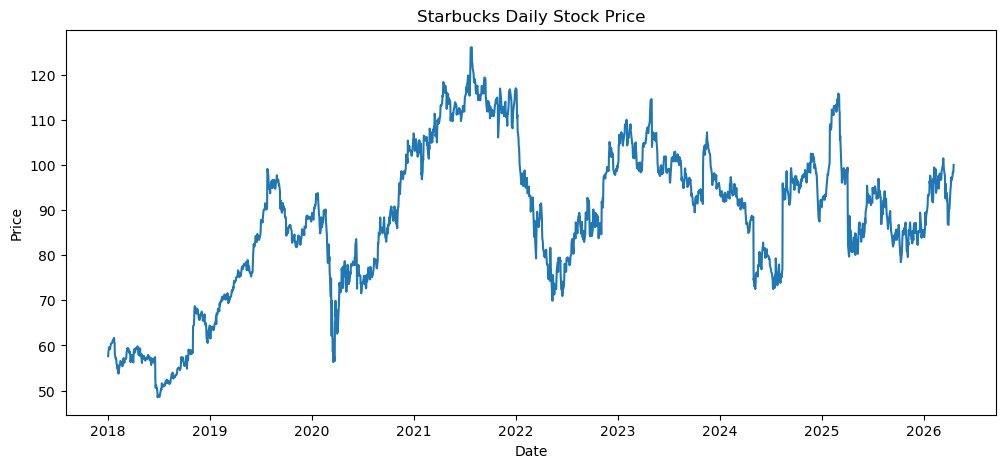

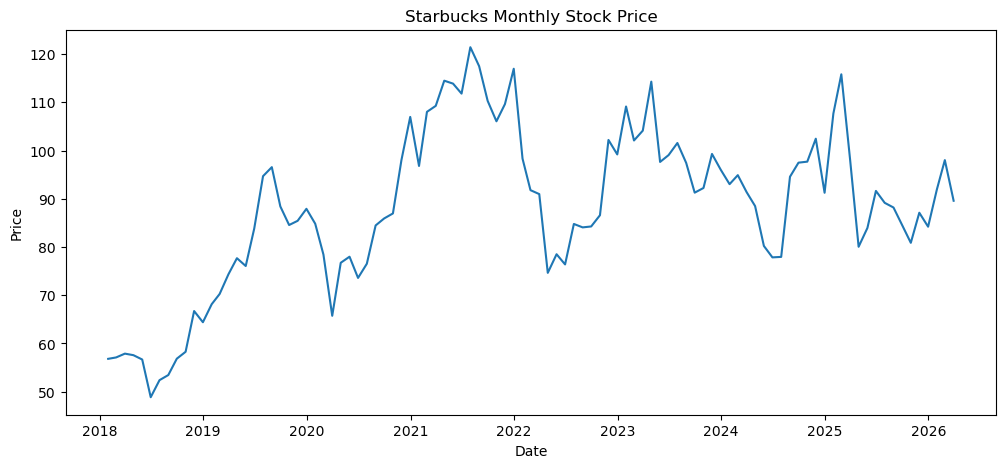

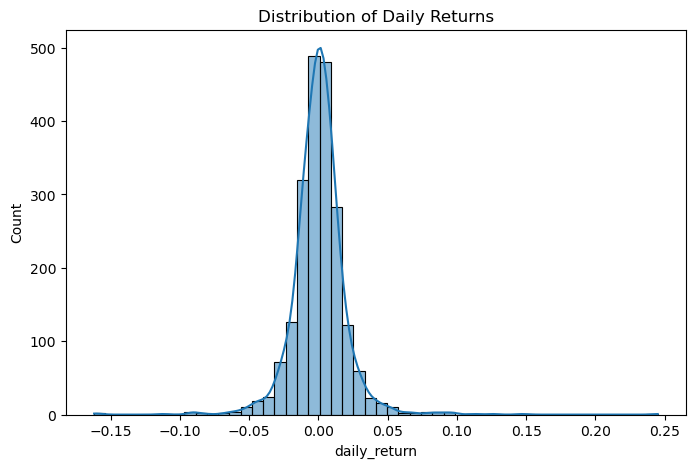

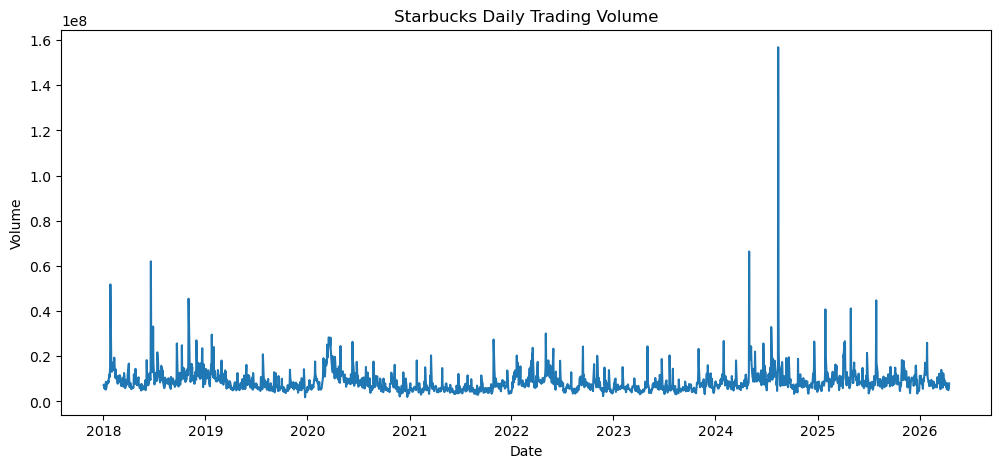

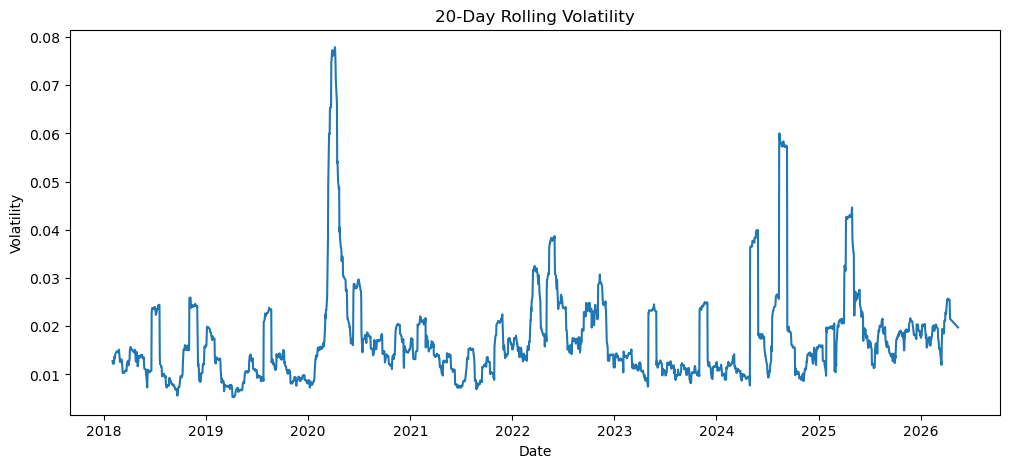

In [54]:
#Daily stock price trend
plt.figure(figsize=(12,5))
plt.plot(daily['datadate'], daily['prccd'])
plt.title("Starbucks Daily Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

#Monthly stock price trends
plt.figure(figsize=(12,5))
plt.plot(monthly['datadate'], monthly['prccm'])
plt.title("Starbucks Monthly Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

#Daily return distribution
plt.figure(figsize=(8,5))
sns.histplot(daily['daily_return'].dropna(), bins=50, kde=True)
plt.title("Distribution of Daily Returns")
plt.show()

#Volume changes
plt.figure(figsize=(12,5))
plt.plot(daily['datadate'], daily['cshtrd'])
plt.title("Starbucks Daily Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

#Twenty-day volatility
plt.figure(figsize=(12,5))
plt.plot(daily['datadate'], daily['volatility_20d'])
plt.title("20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

In [20]:
import pandas as pd

sbux_daily = pd.read_csv(r"C:\starbucks-data-project\data\sbux_daily.csv")
sbux_monthly = pd.read_csv(r"C:\starbucks-data-project\data\sbux_monthly.csv")
sp500_price = pd.read_csv(r"C:\starbucks-data-project\data\sp500_financials_price_data.csv")

print("SBUX Daily:")
print(sbux_daily.head())

print("\nSBUX Monthly:")
print(sbux_monthly.head())

print("\nSP500 Price:")
print(sp500_price.head())

SBUX Daily:
   gvkey  iid    datadate  prccd     cshtrd
0  25434    1  2018-01-02  57.63  7206985.0
1  25434    1  2018-01-03  58.71  7464021.0
2  25434    1  2018-01-04  58.93  5769653.0
3  25434    1  2018-01-05  59.61  6046984.0
4  25434    1  2018-01-08  59.31  6302806.0

SBUX Monthly:
   gvkey  iid    datadate   tic      cusip            conm  ajexm  ajpm  \
0  25434    1  2018-01-31  SBUX  855244109  STARBUCKS CORP    1.0   1.0   
1  25434    1  2018-02-28  SBUX  855244109  STARBUCKS CORP    1.0   1.0   
2  25434    1  2018-03-31  SBUX  855244109  STARBUCKS CORP    1.0   1.0   
3  25434    1  2018-04-30  SBUX  855244109  STARBUCKS CORP    1.0   1.0   
4  25434    1  2018-05-31  SBUX  855244109  STARBUCKS CORP    1.0   1.0   

   isalrt primiss  ...  adrrm cmth         cshom  cyear  mkvalincl  exchg  \
0     NaN       P  ...    NaN    1  1.405314e+09   2018          Y     14   
1     NaN       P  ...    NaN    2  1.405600e+09   2018          Y     14   
2     NaN       P  ...    N

In [21]:
print("SBUX Daily Columns:", sbux_daily.columns.tolist())
print("SBUX Monthly Columns:", sbux_monthly.columns.tolist())
print("SP500 Price Columns:", sp500_price.columns.tolist())

SBUX Daily Columns: ['gvkey', 'iid', 'datadate', 'prccd', 'cshtrd']
SBUX Monthly Columns: ['gvkey', 'iid', 'datadate', 'tic', 'cusip', 'conm', 'ajexm', 'ajpm', 'isalrt', 'primiss', 'cheqvm', 'curcddvm', 'dvpspm', 'dvpsxm', 'dvrate', 'csfsm', 'cshtrm', 'curcdm', 'navm', 'prccm', 'prchm', 'prclm', 'trfm', 'trt1m', 'rawpm', 'rawxm', 'sph100', 'sphcusip', 'sphiid', 'sphmid', 'sphname', 'sphsec', 'sphtic', 'sphvg', 'cshoq', 'adrrm', 'cmth', 'cshom', 'cyear', 'mkvalincl', 'exchg', 'secstat', 'tpci', 'cik', 'fic']
SP500 Price Columns: ['Ticker', 'AON', 'AON.1', 'AON.2', 'AON.3', 'AON.4', 'AON.5', 'MCO', 'MCO.1', 'MCO.2', 'MCO.3', 'MCO.4', 'MCO.5', 'ERIE', 'ERIE.1', 'ERIE.2', 'ERIE.3', 'ERIE.4', 'ERIE.5', 'NTRS', 'NTRS.1', 'NTRS.2', 'NTRS.3', 'NTRS.4', 'NTRS.5', 'ICE', 'ICE.1', 'ICE.2', 'ICE.3', 'ICE.4', 'ICE.5', 'BRK-B', 'BRK-B.1', 'BRK-B.2', 'BRK-B.3', 'BRK-B.4', 'BRK-B.5', 'TROW', 'TROW.1', 'TROW.2', 'TROW.3', 'TROW.4', 'TROW.5', 'CFG', 'CFG.1', 'CFG.2', 'CFG.3', 'CFG.4', 'CFG.5', 'STT', 'S

In [22]:
import pandas as pd
import numpy as np

# 1. Calculate the return function
def calculate_return(price_series):
    """
    Input: Price sequence
    Output: Yield sequence
    """
    return price_series.pct_change()

# 2. Calculate the cumulative return function
def calculate_cumulative_return(return_series):
    """
    Input: Yield rate sequence
    Output: Cumulative yield rate sequence
    """
    return (1 + return_series).cumprod() - 1

# 3. Calculate the standardized price function
def normalize_price(price_series, base=100):
    """
    Input: Price sequence
    Output: Standardized price sequence (default starting point is 100)
    """
    return price_series / price_series.iloc[0] * base

In [27]:
print(sp500_price.head())
print(sp500_price.iloc[:10, :15])

       Ticker                 AON               AON.1               AON.2  \
0       Price                Open                High                 Low   
1        Date                 NaN                 NaN                 NaN   
2  2020-01-02   209.1999969482422   209.8800048828125  207.88999938964844   
3  2020-01-03  207.00999450683594  208.91000366210938  207.00999450683594   
4  2020-01-06  207.22999572753906  208.57000732421875  206.77000427246094   

                AON.3               AON.4   AON.5                 MCO  \
0               Close           Adj Close  Volume                Open   
1                 NaN                 NaN     NaN                 NaN   
2   208.7899932861328  199.30616760253906  830100  238.67999267578125   
3  207.97000122070312         198.5234375  501700  238.82000732421875   
4  208.57000732421875  199.09617614746094  740600   239.6699981689453   

                MCO.1               MCO.2  ... COIN.2 COIN.3     COIN.4  \
0                High  

In [32]:
import pandas as pd
import numpy as np

# read file
sp500 = pd.read_csv(r"C:\starbucks-data-project\data\sp500_financials_price_data.csv")

# View column names
print("Original column names:")
print(sp500.columns.tolist()[:20])

# ---------- Step 1: Change the first column to Date ----------
first_col = sp500.columns[0]
sp500.rename(columns={first_col: "Date"}, inplace=True)

# Convert Date sp500["Date"] = pd.to_datetime(sp500["Date"], errors="coerce")

# Delete rows with invalid dates sp500 = sp500.dropna(subset=["Date"])

# ---------- Step 2: Select the first column of each group of stocks as the price column ----------
# Based on your current structure, for example, AON, AON.1, AON.2, ... among a group, the main column usually does not have the ".1"/".2" suffix. price_cols = [col for col in sp500.columns if col != "Date" and "." not in col]

print("\nThe number of identified price columns: ", len(price_cols))
print("The first 10 price columns: ", price_cols[:10]) 
# ---------- Step 3: Convert to Numerical Values ---------- for col in price_cols:
sp500[col] = pd.to_numeric(sp500[col], errors="coerce")

# ---------- Step 4: Construct proxy ----------
# Take the horizontal average of all price columns to form a market proxy sequence sp500["SP500_Proxy"] = sp500[price_cols].mean(axis=1)

# Delete rows where the proxy is empty sp500 = sp500.dropna(subset=["SP500_Proxy"])

# Sort by Date sp500 = sp500.sort_values("Date")

# ---------- Step 5: Standardization ---------- first_valid = sp500["SP500_Proxy"].dropna().iloc[0]
sp500["SP500_Proxy_Normalized"] = sp500["SP500_Proxy"] / first_valid * 100

# ---------- Step 6: Output the standardized file ---------- sp500_standardized = sp500[["Date", "SP500_Proxy", "SP500_Proxy_Normalized"]].copy()

# Step 7: Save the file output_path = r"C:\starbucks-data-project\data\sp500_standardized.csv"
sp500_standardized.to_csv(output_path, index=False)

# Step 8: View the results
print("\nStandardized SP500 proxy:") print(sp500_standardized.head())

print("\nThe file has been saved at: ") print(output_path)

原始列名：
['Ticker', 'AON', 'AON.1', 'AON.2', 'AON.3', 'AON.4', 'AON.5', 'MCO', 'MCO.1', 'MCO.2', 'MCO.3', 'MCO.4', 'MCO.5', 'ERIE', 'ERIE.1', 'ERIE.2', 'ERIE.3', 'ERIE.4', 'ERIE.5', 'NTRS']

识别出的价格列数量： 76
前10个价格列： ['AON', 'MCO', 'ERIE', 'NTRS', 'ICE', 'BRK-B', 'TROW', 'CFG', 'STT', 'ALL']

标准化后的SP500 proxy：
        Date  SP500_Proxy  SP500_Proxy_Normalized
2 2020-01-02   115.490567              100.000000
3 2020-01-03   114.572403               99.204988
4 2020-01-06   114.630680               99.255449
5 2020-01-07   115.400136               99.921698
6 2020-01-08   115.440884               99.956981

文件已保存到：
C:\starbucks-data-project\data\sp500_standardized.csv


C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_6756\2053210021.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sp500["Date"] = pd.to_datetime(sp500["Date"], errors="coerce")
C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_6756\2053210021.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sp500["SP500_Proxy"] = sp500[price_cols].mean(axis=1)


sbux_daily columns: ['gvkey', 'iid', 'datadate', 'prccd', 'cshtrd']
sbux_monthly columns: ['gvkey', 'iid', 'datadate', 'tic', 'cusip', 'conm', 'ajexm', 'ajpm', 'isalrt', 'primiss', 'cheqvm', 'curcddvm', 'dvpspm', 'dvpsxm', 'dvrate', 'csfsm', 'cshtrm', 'curcdm', 'navm', 'prccm', 'prchm', 'prclm', 'trfm', 'trt1m', 'rawpm', 'rawxm', 'sph100', 'sphcusip', 'sphiid', 'sphmid', 'sphname', 'sphsec', 'sphtic', 'sphvg', 'cshoq', 'adrrm', 'cmth', 'cshom', 'cyear', 'mkvalincl', 'exchg', 'secstat', 'tpci', 'cik', 'fic']
sp500 columns: ['Date', 'SP500_Proxy', 'SP500_Proxy_Normalized']


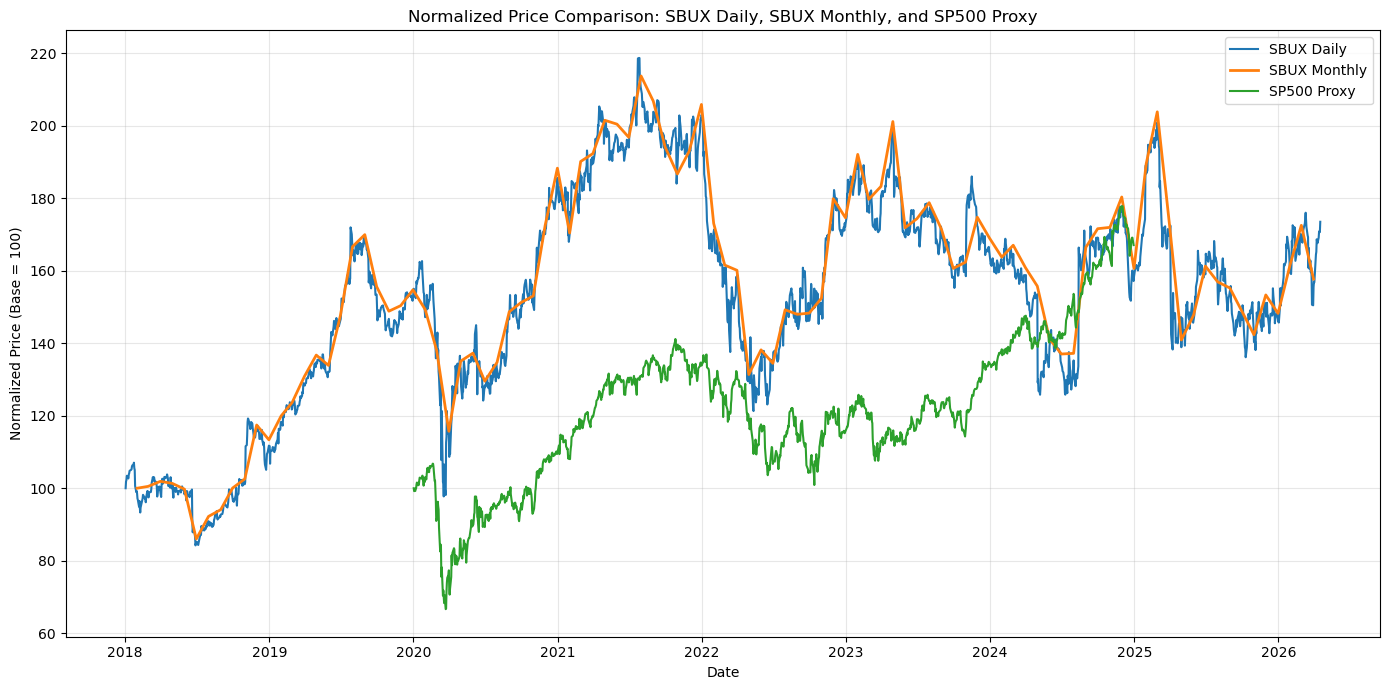


Common-date comparison table:
        Date  SBUX_Daily_Normalized  SBUX_Monthly_Normalized  \
0 2020-01-31             147.197640               149.322302   
1 2020-03-31             114.072532               115.719064   
2 2020-04-30             133.142461               135.064249   
3 2020-06-30             127.693909               129.537053   
4 2020-07-31             132.795419               134.712199   

   SP500_Proxy_Normalized  
0              103.055879  
1               77.337039  
2               84.455563  
3               89.273461  
4               95.134254  


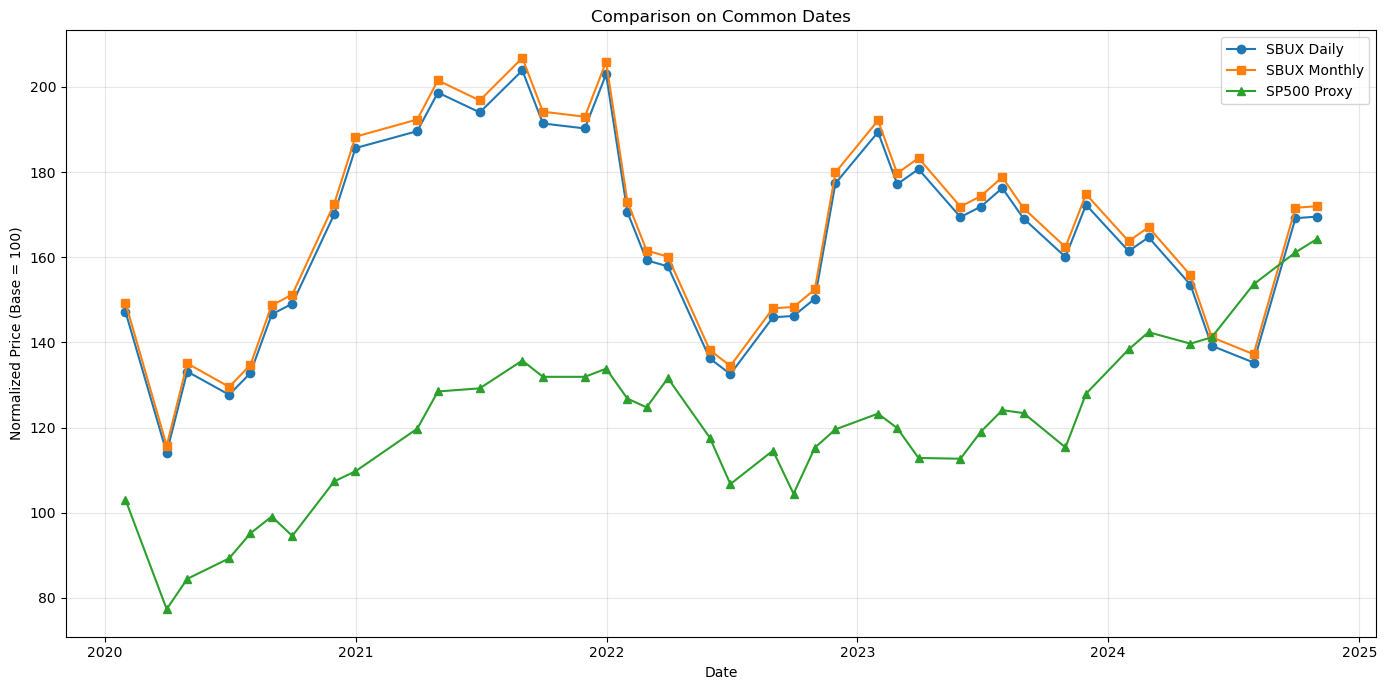


Descriptive statistics:
       SBUX_Daily_Normalized  SBUX_Monthly_Normalized  SP500_Proxy_Normalized
count              41.000000                41.000000               41.000000
mean              163.713428               166.076481              120.757332
std                22.523302                22.848405               19.041689
min               114.072532               115.719064               77.337039
25%               146.572965               148.688611              109.717631
50%               169.078605               171.519099              119.855830
75%               177.338192               179.897905              131.903431
max               203.869512               206.812181              164.240818

Growth summary:
         Series       Start         End   Growth_%
0    SBUX Daily  147.197640  169.529759  15.171520
1  SBUX Monthly  149.322302  171.976765  15.171520
2   SP500 Proxy  103.055879  164.240818  59.370643


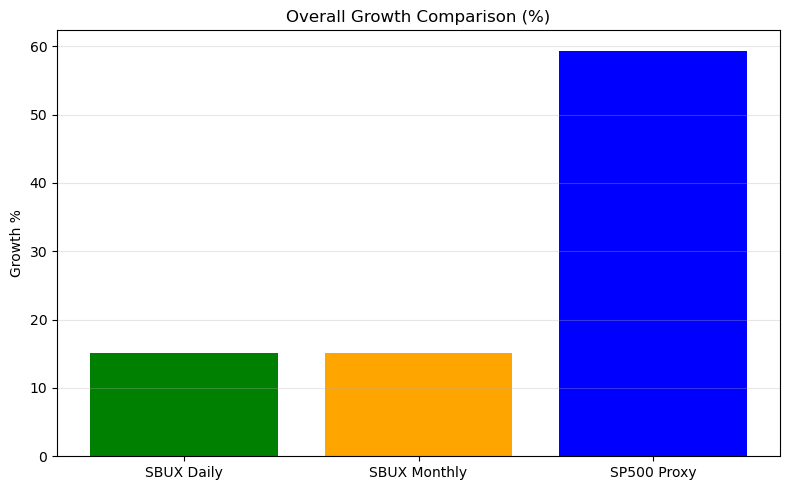


Volatility (std):
SBUX_Daily_Normalized      22.523302
SBUX_Monthly_Normalized    22.848405
SP500_Proxy_Normalized     19.041689
dtype: float64


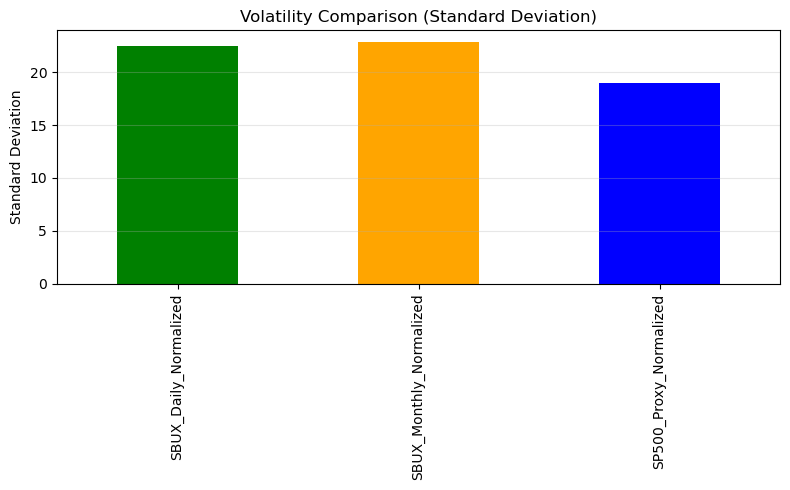

In [41]:
#Compared with the SP500 Index
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Read data
# =========================
sbux_daily = pd.read_csv(r"C:\starbucks-data-project\data\sbux_daily.csv")
sbux_monthly = pd.read_csv(r"C:\starbucks-data-project\data\sbux_monthly.csv")
sp500_standardized = pd.read_csv(r"C:\starbucks-data-project\data\sp500_standardized.csv")

# =========================
# 2. Check column names
# =========================
print("sbux_daily columns:", sbux_daily.columns.tolist())
print("sbux_monthly columns:", sbux_monthly.columns.tolist())
print("sp500 columns:", sp500_standardized.columns.tolist())

# =========================
# 3. Organizing Starbucks Daily
# Assume the daily date column is called "datadate" and the price column is called "prccd"
# =========================
sbux_daily_use = sbux_daily[["datadate", "prccd"]].copy()
sbux_daily_use = sbux_daily_use.rename(columns={
    "datadate": "Date",
    "prccd": "Close"
})

sbux_daily_use["Date"] = pd.to_datetime(sbux_daily_use["Date"], errors="coerce")
sbux_daily_use["Close"] = pd.to_numeric(sbux_daily_use["Close"], errors="coerce")

sbux_daily_use = sbux_daily_use.dropna(subset=["Date", "Close"])
sbux_daily_use = sbux_daily_use.sort_values("Date")

first_daily = sbux_daily_use["Close"].iloc[0]
sbux_daily_use["SBUX_Daily_Normalized"] = sbux_daily_use["Close"] / first_daily * 100

# =========================
# 4. Organize Starbucks Monthly
# Set the monthly date column as "datadate" and the price column as "prccm"
# =========================
sbux_monthly_use = sbux_monthly[["datadate", "prccm"]].copy()
sbux_monthly_use = sbux_monthly_use.rename(columns={
    "datadate": "Date",
    "prccm": "Close"
})

sbux_monthly_use["Date"] = pd.to_datetime(sbux_monthly_use["Date"], errors="coerce")
sbux_monthly_use["Close"] = pd.to_numeric(sbux_monthly_use["Close"], errors="coerce")

sbux_monthly_use = sbux_monthly_use.dropna(subset=["Date", "Close"])
sbux_monthly_use = sbux_monthly_use.sort_values("Date")

first_monthly = sbux_monthly_use["Close"].iloc[0]
sbux_monthly_use["SBUX_Monthly_Normalized"] = sbux_monthly_use["Close"] / first_monthly * 100

# =========================
# 5. Organize SP500 Proxy
# =========================
sp500_standardized["Date"] = pd.to_datetime(sp500_standardized["Date"], errors="coerce")
sp500_standardized["SP500_Proxy_Normalized"] = pd.to_numeric(
    sp500_standardized["SP500_Proxy_Normalized"], errors="coerce"
)

sp500_standardized = sp500_standardized.dropna(subset=["Date", "SP500_Proxy_Normalized"])
sp500_standardized = sp500_standardized.sort_values("Date")

# =========================
# 6. Draw a trend chart of the three
# =========================
plt.figure(figsize=(14, 7))

plt.plot(
    sbux_daily_use["Date"],
    sbux_daily_use["SBUX_Daily_Normalized"],
    label="SBUX Daily",
    linewidth=1.5
)

plt.plot(
    sbux_monthly_use["Date"],
    sbux_monthly_use["SBUX_Monthly_Normalized"],
    label="SBUX Monthly",
    linewidth=2
)

plt.plot(
    sp500_standardized["Date"],
    sp500_standardized["SP500_Proxy_Normalized"],
    label="SP500 Proxy",
    linewidth=1.5
)

plt.title("Normalized Price Comparison: SBUX Daily, SBUX Monthly, and SP500 Proxy")
plt.xlabel("Date")
plt.ylabel("Normalized Price (Base = 100)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# 7. Merge common date
# =========================
comparison_inner = pd.merge(
    sbux_daily_use[["Date", "SBUX_Daily_Normalized"]],
    sbux_monthly_use[["Date", "SBUX_Monthly_Normalized"]],
    on="Date",
    how="inner"
)

comparison_inner = pd.merge(
    comparison_inner,
    sp500_standardized[["Date", "SP500_Proxy_Normalized"]],
    on="Date",
    how="inner"
)

comparison_inner = comparison_inner.sort_values("Date")

print("\nCommon-date comparison table:")
print(comparison_inner.head())

# =========================
# 8. Common date trend chart
# =========================
plt.figure(figsize=(14, 7))

plt.plot(
    comparison_inner["Date"],
    comparison_inner["SBUX_Daily_Normalized"],
    label="SBUX Daily",
    marker="o",
    linewidth=1.5
)

plt.plot(
    comparison_inner["Date"],
    comparison_inner["SBUX_Monthly_Normalized"],
    label="SBUX Monthly",
    marker="s",
    linewidth=1.5
)

plt.plot(
    comparison_inner["Date"],
    comparison_inner["SP500_Proxy_Normalized"],
    label="SP500 Proxy",
    marker="^",
    linewidth=1.5
)

plt.title("Comparison on Common Dates")
plt.xlabel("Date")
plt.ylabel("Normalized Price (Base = 100)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# 9. Descriptive statistics
# =========================
print("\nDescriptive statistics:")
print(comparison_inner[[
    "SBUX_Daily_Normalized",
    "SBUX_Monthly_Normalized",
    "SP500_Proxy_Normalized"
]].describe())

# =========================
# 10. Overall increase comparison
# =========================
summary = pd.DataFrame({
    "Series": ["SBUX Daily", "SBUX Monthly", "SP500 Proxy"],
    "Start": [
        comparison_inner["SBUX_Daily_Normalized"].iloc[0],
        comparison_inner["SBUX_Monthly_Normalized"].iloc[0],
        comparison_inner["SP500_Proxy_Normalized"].iloc[0]
    ],
    "End": [
        comparison_inner["SBUX_Daily_Normalized"].iloc[-1],
        comparison_inner["SBUX_Monthly_Normalized"].iloc[-1],
        comparison_inner["SP500_Proxy_Normalized"].iloc[-1]
    ]
})

summary["Growth_%"] = (summary["End"] / summary["Start"] - 1) * 100

print("\nGrowth summary:")
print(summary)

# Increase histogram
plt.figure(figsize=(8, 5))
plt.bar(summary["Series"], summary["Growth_%"], color=["green", "orange", "blue"])
plt.title("Overall Growth Comparison (%)")
plt.ylabel("Growth %")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# 11. Volatility comparison
# =========================
volatility = comparison_inner[[
    "SBUX_Daily_Normalized",
    "SBUX_Monthly_Normalized",
    "SP500_Proxy_Normalized"
]].std()

print("\nVolatility (std):")
print(volatility)

plt.figure(figsize=(8, 5))
volatility.plot(kind="bar", color=["green", "orange", "blue"])
plt.title("Volatility Comparison (Standard Deviation)")
plt.ylabel("Standard Deviation")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

# Example financial data for Starbucks
# Replace these values with actual annual report data
data = {
    "Year": [2020, 2021, 2022, 2023],
    "Net Income": [928.3, 4199.3, 3281.6, 4124.5],
    "Revenue": [23518.0, 29461.6, 32250.6, 35976.2],
    "Total Assets": [29187.5, 31792.8, 28126.2, 29972.1],
    "Equity": [-7678.4, -7899.6, -8242.8, -8170.5]
}

sbux_dupont = pd.DataFrame(data)
sbux_dupont = sbux_dupont.set_index("Year")

# Calculate DuPont ratios
sbux_dupont["Profit Margin"] = sbux_dupont["Net Income"] / sbux_dupont["Revenue"]
sbux_dupont["Asset Turnover"] = sbux_dupont["Revenue"] / sbux_dupont["Total Assets"]
sbux_dupont["Equity Multiplier"] = sbux_dupont["Total Assets"] / sbux_dupont["Equity"]
sbux_dupont["ROE"] = sbux_dupont["Profit Margin"] * sbux_dupont["Asset Turnover"] * sbux_dupont["Equity Multiplier"]

print(sbux_dupont)

      Net Income  Revenue  Total Assets  Equity  Profit Margin  \
Year                                                             
2020       928.3  23518.0       29187.5 -7678.4       0.039472   
2021      4199.3  29461.6       31792.8 -7899.6       0.142535   
2022      3281.6  32250.6       28126.2 -8242.8       0.101753   
2023      4124.5  35976.2       29972.1 -8170.5       0.114645   

      Asset Turnover  Equity Multiplier       ROE  
Year                                               
2020        0.805756          -3.801248 -0.120898  
2021        0.926675          -4.024609 -0.531584  
2022        1.146639          -3.412214 -0.398117  
2023        1.200323          -3.668331 -0.504804  


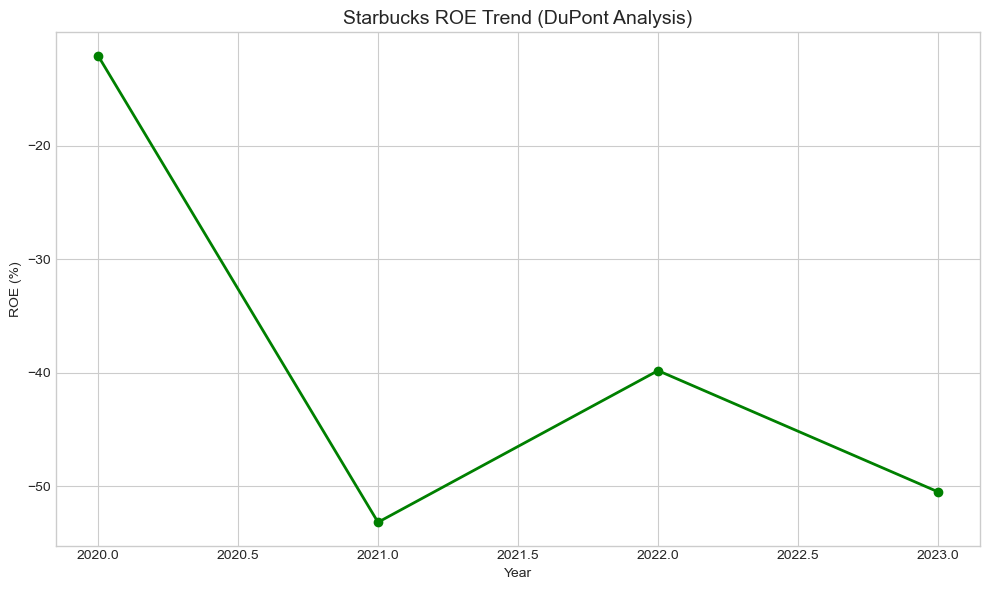

In [63]:
plt.figure(figsize=(10, 6))
plt.plot(sbux_dupont.index, sbux_dupont["ROE"] * 100, marker="o", linewidth=2, color="green")
plt.title("Starbucks ROE Trend (DuPont Analysis)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("ROE (%)")
plt.tight_layout()
plt.show()

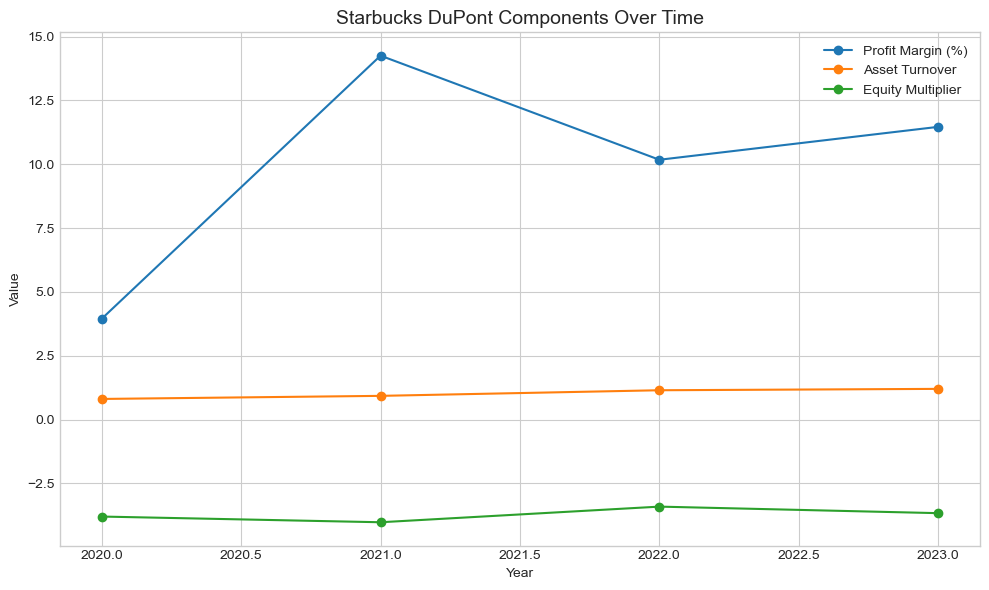

In [64]:
plt.figure(figsize=(10, 6))
plt.plot(sbux_dupont.index, sbux_dupont["Profit Margin"] * 100, marker="o", label="Profit Margin (%)")
plt.plot(sbux_dupont.index, sbux_dupont["Asset Turnover"], marker="o", label="Asset Turnover")
plt.plot(sbux_dupont.index, sbux_dupont["Equity Multiplier"], marker="o", label="Equity Multiplier")

plt.title("Starbucks DuPont Components Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

def dupont_analysis(data):
    """
    Perform DuPont analysis from a financial data DataFrame.

    Parameters:
    data : pd.DataFrame
        Must contain the following columns:
        ['Year', 'Net Income', 'Revenue', 'Total Assets', 'Equity']

    Returns:
    pd.DataFrame
        DataFrame with DuPont components and ROE.
    """
    df = data.copy()
    df = df.set_index("Year")

    df["Profit Margin"] = df["Net Income"] / df["Revenue"]
    df["Asset Turnover"] = df["Revenue"] / df["Total Assets"]
    df["Equity Multiplier"] = df["Total Assets"] / df["Equity"]
    df["ROE"] = df["Profit Margin"] * df["Asset Turnover"] * df["Equity Multiplier"]

    return df